# Steel Defect Classification Pipeline

Pipeline klasifikasi untuk pre-screening gambar steel defect sebelum segmentasi.
Menggunakan random crop, defect blackout augmentation, dan model ensemble.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import timm

import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

## 2. Configuration

In [2]:
DATA_DIR = Path('/kaggle/input/severstal-steel-defect-detection')
TRAIN_DIR = DATA_DIR / 'train_images'
TEST_DIR = DATA_DIR / 'test_images'
TRAIN_CSV = DATA_DIR / 'train.csv'
SAMPLE_SUB = DATA_DIR / 'sample_submission.csv'

CROP_HEIGHT = 224
CROP_WIDTH = 1568
NUM_CLASSES = 4
BATCH_SIZE_EFFICIENT = 8
BATCH_SIZE_RESNET = 16
ACCUMULATION_STEPS = 4
NUM_EPOCHS = 20
LEARNING_RATE = 0.01
MOMENTUM = 0.9
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
THRESHOLD = [0.6, 0.6, 0.6, 0.6]

print(f'Using device: {DEVICE}')

Using device: cuda


## 3. RLE Utilities

In [3]:
def rle_to_mask(rle_string, height=256, width=1600):
    if pd.isna(rle_string) or rle_string == '':
        return np.zeros((height, width), dtype=np.uint8)
    
    s = rle_string.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0::2], s[1::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(height * width, dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape((height, width), order='F')

def build_masks(df, image_id, height=256, width=1600):
    masks = np.zeros((height, width, NUM_CLASSES), dtype=np.uint8)
    for class_id in range(1, NUM_CLASSES + 1):
        mask_data = df[(df['ImageId'] == image_id) & (df['ClassId'] == class_id)]
        if not mask_data.empty:
            rle = mask_data.iloc[0]['EncodedPixels']
            masks[:, :, class_id - 1] = rle_to_mask(rle, height, width)
    return masks

def get_labels(df, image_id):
    labels = np.zeros(NUM_CLASSES, dtype=np.float32)
    for class_id in range(1, NUM_CLASSES + 1):
        mask_data = df[(df['ImageId'] == image_id) & (df['ClassId'] == class_id)]
        if not mask_data.empty and not pd.isna(mask_data.iloc[0]['EncodedPixels']):
            labels[class_id - 1] = 1.0
    return labels

## 4. Load Data

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
sample_sub = pd.read_csv(SAMPLE_SUB)

print(f'Training data shape: {train_df.shape}')
print(f'Unique images: {train_df["ImageId"].nunique()}')
print(f'\nClass distribution:')
for class_id in range(1, NUM_CLASSES + 1):
    has_defect = train_df[(train_df['ClassId'] == class_id) & (~train_df['EncodedPixels'].isna())]
    print(f'Class {class_id}: {len(has_defect)} images with defects')

Training data shape: (7095, 3)
Unique images: 6666

Class distribution:
Class 1: 897 images with defects
Class 2: 247 images with defects
Class 3: 5150 images with defects
Class 4: 801 images with defects


## 5. Custom Augmentations - Defect Blackout

In [5]:
class DefectBlackout:
    def __init__(self, p=0.5):
        self.p = p
    
    def __call__(self, image, masks, labels):
        if np.random.random() < self.p:
            new_labels = labels.copy()
            for i in range(NUM_CLASSES):
                if labels[i] == 1 and np.random.random() < 0.5:
                    mask = masks[:, :, i]
                    image[mask > 0] = 0
                    new_labels[i] = 0
            return image, new_labels
        return image, labels

## 6. Dataset Class

In [6]:
class SteelClassificationDataset(Dataset):
    def __init__(self, df, image_ids, img_dir, transform=None, defect_blackout=None, is_test=False, tta_mode=None):
        self.df = df
        self.image_ids = image_ids
        self.img_dir = img_dir
        self.transform = transform
        self.defect_blackout = defect_blackout
        self.is_test = is_test
        self.tta_mode = tta_mode
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = self.img_dir / image_id
        
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.is_test:
            if self.tta_mode == 'hflip':
                image = cv2.flip(image, 1)
            elif self.tta_mode == 'vflip':
                image = cv2.flip(image, 0)
            
            if self.transform:
                augmented = self.transform(image=image)
                image = augmented['image']
            return image, image_id
        
        labels = get_labels(self.df, image_id)
        masks = build_masks(self.df, image_id, image.shape[0], image.shape[1])
        
        if self.defect_blackout:
            image, labels = self.defect_blackout(image, masks, labels)
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        return image, torch.FloatTensor(labels)

## 7. Data Augmentation

In [7]:
train_transform = A.Compose([
    A.RandomCrop(height=CROP_HEIGHT, width=CROP_WIDTH, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

defect_blackout = DefectBlackout(p=0.5)

## 8. Prepare Data Splits

In [8]:
all_image_ids = train_df['ImageId'].unique()
train_ids, val_ids = train_test_split(all_image_ids, test_size=0.2, random_state=42)

print(f'Training samples: {len(train_ids)}')
print(f'Validation samples: {len(val_ids)}')

Training samples: 5332
Validation samples: 1334


## 9. Model Definition

In [9]:
class SteelClassifier(nn.Module):
    def __init__(self, model_name='efficientnet_b1', num_classes=4, pretrained=True):
        super(SteelClassifier, self).__init__()
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    
    def forward(self, x):
        return self.model(x)

def create_model(model_name, device):
    model = SteelClassifier(model_name=model_name, num_classes=NUM_CLASSES)
    model = model.to(device)
    return model

## 10. Training Functions

In [10]:
def train_epoch(model, loader, criterion, optimizer, device, scaler, accumulation_steps):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    optimizer.zero_grad()
    
    for i, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels) / accumulation_steps
        
        scaler.scale(loss).backward()
        
        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        total_loss += loss.item() * accumulation_steps
        
        with torch.no_grad():
            preds = torch.sigmoid(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    auc_scores = []
    for i in range(NUM_CLASSES):
        if len(np.unique(all_labels[:, i])) > 1:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(auc)
    
    avg_auc = np.mean(auc_scores) if auc_scores else 0.0
    
    return total_loss / len(loader), avg_auc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            preds = torch.sigmoid(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    auc_scores = []
    for i in range(NUM_CLASSES):
        if len(np.unique(all_labels[:, i])) > 1:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(auc)
    
    avg_auc = np.mean(auc_scores) if auc_scores else 0.0
    
    return total_loss / len(loader), avg_auc

## 11. Train Model - EfficientNet-B1

In [11]:
def train_model(model_name, batch_size, model_path):
    train_dataset = SteelClassificationDataset(
        train_df, train_ids, TRAIN_DIR, 
        transform=train_transform, 
        defect_blackout=defect_blackout
    )
    val_dataset = SteelClassificationDataset(
        train_df, val_ids, TRAIN_DIR, 
        transform=val_transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    model = create_model(model_name, DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = GradScaler()
    
    best_auc = 0
    history = {'train_loss': [], 'train_auc': [], 'val_loss': [], 'val_auc': []}
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_auc = train_epoch(
            model, train_loader, criterion, optimizer, DEVICE, scaler, ACCUMULATION_STEPS
        )
        val_loss, val_auc = validate_epoch(model, val_loader, criterion, DEVICE)
        
        history['train_loss'].append(train_loss)
        history['train_auc'].append(train_auc)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        
        scheduler.step()
        
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
        print(f'Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}')
        
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), model_path)
            print(f'Model saved with AUC: {best_auc:.4f}')
        print('-' * 50)
    
    return history

print('Training EfficientNet-B1 models...')
history_eff_1 = train_model('efficientnet_b1', BATCH_SIZE_EFFICIENT, 'efficientnet_b1_fold1.pth')
history_eff_2 = train_model('efficientnet_b1', BATCH_SIZE_EFFICIENT, 'efficientnet_b1_fold2.pth')
history_eff_3 = train_model('efficientnet_b1', BATCH_SIZE_EFFICIENT, 'efficientnet_b1_fold3.pth')

Training EfficientNet-B1 models...


model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

Epoch 1/20
Train Loss: 0.4377, Train AUC: 0.6910
Val Loss: 0.3273, Val AUC: 0.8020
Model saved with AUC: 0.8020
--------------------------------------------------
Epoch 2/20
Train Loss: 0.2628, Train AUC: 0.8402
Val Loss: 0.2946, Val AUC: 0.8646
Model saved with AUC: 0.8646
--------------------------------------------------
Epoch 3/20
Train Loss: 0.2357, Train AUC: 0.8840
Val Loss: 0.2496, Val AUC: 0.9085
Model saved with AUC: 0.9085
--------------------------------------------------
Epoch 4/20
Train Loss: 0.2173, Train AUC: 0.9048
Val Loss: 0.2562, Val AUC: 0.9012
--------------------------------------------------
Epoch 5/20
Train Loss: 0.1963, Train AUC: 0.9268
Val Loss: 0.2403, Val AUC: 0.9269
Model saved with AUC: 0.9269
--------------------------------------------------
Epoch 6/20
Train Loss: 0.1827, Train AUC: 0.9355
Val Loss: 0.1765, Val AUC: 0.9438
Model saved with AUC: 0.9438
--------------------------------------------------
Epoch 7/20
Train Loss: 0.1593, Train AUC: 0.9550
Va

## 12. Train Model - ResNet34

In [12]:
print('Training ResNet34 model## 13. Prediction with TTA (Test Time Augmentation)...')
history_resnet = train_model('resnet34', BATCH_SIZE_RESNET, 'resnet34.pth')

Training ResNet34 model## 13. Prediction with TTA (Test Time Augmentation)...


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1/20
Train Loss: 0.3906, Train AUC: 0.5494
Val Loss: 0.3842, Val AUC: 0.6040
Model saved with AUC: 0.6040
--------------------------------------------------
Epoch 2/20
Train Loss: 0.3482, Train AUC: 0.6445
Val Loss: 0.3790, Val AUC: 0.6727
Model saved with AUC: 0.6727
--------------------------------------------------
Epoch 3/20
Train Loss: 0.3459, Train AUC: 0.6975
Val Loss: 0.3685, Val AUC: 0.6994
Model saved with AUC: 0.6994
--------------------------------------------------
Epoch 4/20
Train Loss: 0.3382, Train AUC: 0.7296
Val Loss: 0.3577, Val AUC: 0.7416
Model saved with AUC: 0.7416
--------------------------------------------------
Epoch 5/20
Train Loss: 0.3334, Train AUC: 0.7437
Val Loss: 0.3488, Val AUC: 0.7591
Model saved with AUC: 0.7591
--------------------------------------------------
Epoch 6/20
Train Loss: 0.3297, Train AUC: 0.7587
Val Loss: 0.3469, Val AUC: 0.7719
Model saved with AUC: 0.7719
--------------------------------------------------
Epoch 7/20
Train Loss:

## 13. Prediction with TTA (Test Time Augmentation)

In [13]:
def predict_with_tta(model, loader, device):
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)
            predictions.append(preds.cpu().numpy())
    
    return np.vstack(predictions)

def get_test_predictions(model_paths, model_names, test_ids, tta_modes=['none', 'hflip', 'vflip']):
    all_predictions = []
    
    for model_path, model_name in zip(model_paths, model_names):
        model = create_model(model_name, DEVICE)
        model.load_state_dict(torch.load(model_path))
        
        for tta_mode in tta_modes:
            tta = tta_mode if tta_mode != 'none' else None
            
            test_dataset = SteelClassificationDataset(
                None, test_ids, TEST_DIR, 
                transform=val_transform, 
                is_test=True, 
                tta_mode=tta
            )
            test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)
            
            preds = predict_with_tta(model, test_loader, DEVICE)
            all_predictions.append(preds)
            print(f'Predictions from {model_name} with TTA={tta_mode}: {preds.shape}')
    
    ensemble_preds = np.mean(all_predictions, axis=0)
    return ensemble_preds

## 14. Generate Predictions

In [14]:
test_images = sorted([f.name for f in TEST_DIR.glob('*.jpg')])

model_paths = [
    'efficientnet_b1_fold1.pth',
    'efficientnet_b1_fold2.pth', 
    'efficientnet_b1_fold3.pth',
    'resnet34.pth'
]

model_names = [
    'efficientnet_b1',
    'efficientnet_b1',
    'efficientnet_b1', 
    'resnet34'
]

print('Generating ensemble predictions with TTA...')
ensemble_predictions = get_test_predictions(model_paths, model_names, test_images)
print(f'Ensemble predictions shape: {ensemble_predictions.shape}')

Generating ensemble predictions with TTA...
Predictions from efficientnet_b1 with TTA=none: (5506, 4)
Predictions from efficientnet_b1 with TTA=hflip: (5506, 4)
Predictions from efficientnet_b1 with TTA=vflip: (5506, 4)
Predictions from efficientnet_b1 with TTA=none: (5506, 4)
Predictions from efficientnet_b1 with TTA=hflip: (5506, 4)
Predictions from efficientnet_b1 with TTA=vflip: (5506, 4)
Predictions from efficientnet_b1 with TTA=none: (5506, 4)
Predictions from efficientnet_b1 with TTA=hflip: (5506, 4)
Predictions from efficientnet_b1 with TTA=vflip: (5506, 4)
Predictions from resnet34 with TTA=none: (5506, 4)
Predictions from resnet34 with TTA=hflip: (5506, 4)
Predictions from resnet34 with TTA=vflip: (5506, 4)
Ensemble predictions shape: (5506, 4)


## 15. Apply Threshold and Generate Submission

In [15]:
binary_predictions = np.zeros_like(ensemble_predictions)
for i in range(NUM_CLASSES):
    binary_predictions[:, i] = (ensemble_predictions[:, i] >= THRESHOLD[i]).astype(int)

results = []
for idx, image_id in enumerate(test_images):
    for class_id in range(1, NUM_CLASSES + 1):
        has_defect = binary_predictions[idx, class_id - 1]
        results.append({
            'ImageId': image_id,
            'ClassId': class_id,
            'HasDefect': int(has_defect),
            'Confidence': ensemble_predictions[idx, class_id - 1]
        })

classification_df = pd.DataFrame(results)
classification_df.to_csv('classification_results.csv', index=False)

print('Classification Summary:')
print(f'Total images: {len(test_images)}')
print(f'\nPredicted defects by class:')
for class_id in range(1, NUM_CLASSES + 1):
    count = binary_predictions[:, class_id - 1].sum()
    print(f'Class {class_id}: {count} images ({count/len(test_images)*100:.1f}%)')

images_with_defects = (binary_predictions.sum(axis=1) > 0).sum()
images_without_defects = len(test_images) - images_with_defects
print(f'\nImages with defects: {images_with_defects} ({images_with_defects/len(test_images)*100:.1f}%)')
print(f'Images without defects: {images_without_defects} ({images_without_defects/len(test_images)*100:.1f}%)')

Classification Summary:
Total images: 5506

Predicted defects by class:
Class 1: 489.0 images (8.9%)
Class 2: 83.0 images (1.5%)
Class 3: 3236.0 images (58.8%)
Class 4: 341.0 images (6.2%)

Images with defects: 4094 (74.4%)
Images without defects: 1412 (25.6%)


## 16. Visualization

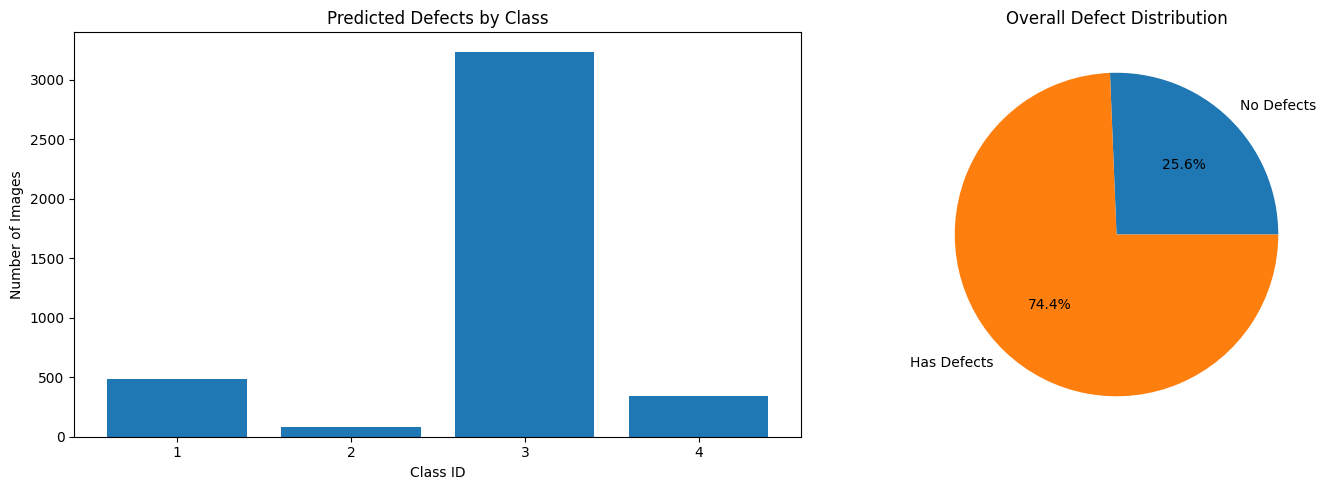


Sample predictions:
          ImageId  ClassId  HasDefect  Confidence
2   0000f269f.jpg        3          1    0.832989
6   000ccc2ac.jpg        3          1    0.662199
10  002451917.jpg        3          1    0.909818
14  003c5da97.jpg        3          1    0.866411
18  0042e163f.jpg        3          1    0.888809
26  00513039a.jpg        3          1    0.931227
34  008725cbc.jpg        3          1    0.889479
38  0098ca44e.jpg        3          1    0.889899
42  00a0b7730.jpg        3          1    0.820151
47  00a0f9949.jpg        4          1    0.652039


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

class_counts = [binary_predictions[:, i].sum() for i in range(NUM_CLASSES)]
axes[0].bar(range(1, NUM_CLASSES + 1), class_counts)
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Predicted Defects by Class')
axes[0].set_xticks(range(1, NUM_CLASSES + 1))

defect_distribution = [images_without_defects, images_with_defects]
axes[1].pie(defect_distribution, labels=['No Defects', 'Has Defects'], autopct='%1.1f%%')
axes[1].set_title('Overall Defect Distribution')

plt.tight_layout()
plt.show()

print('\nSample predictions:')
sample_df = classification_df[classification_df['HasDefect'] == 1].head(10)
print(sample_df)